# Object Detection with YOLOv8

This notebook demonstrates lightweight object detection with the pretrained **YOLOv8 Nano** model. It is designed for CPU-only computers and uses the small COCO8 sample dataset.

## 1. Import the required packages

In [1]:
from pathlib import Path
import zipfile
import requests
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\user\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


## 2. Download the small COCO8 sample dataset

The dataset is downloaded only when needed. Nothing is committed to the Git repository.

In [4]:
DATA_DIR = Path("../data/coco8")
DATA_DIR.mkdir(parents=True, exist_ok=True)
ZIP_PATH = DATA_DIR.parent / "coco8.zip"
DATA_URL = "https://github.com/ultralytics/assets/releases/download/v8.3.0/coco8.zip"

if not ZIP_PATH.exists():
    response = requests.get(DATA_URL, timeout=60)
    if not ZIP_PATH.exists():
        response = requests.get(DATA_URL, timeout=60)
        DATA_URL = "https://github.com/ultralytics/assets/releases/download/v0.0.0/coco8.zip"
        response = requests.get(DATA_URL, timeout=60)
        response.raise_for_status()
        ZIP_PATH.write_bytes(response.content)
    ZIP_PATH.write_bytes(response.content)

extract_dir = DATA_DIR / "dataset"
if not extract_dir.exists():
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(extract_dir)

image_candidates = sorted(extract_dir.rglob("*.jpg"))
print(f"Downloaded sample images: {len(image_candidates)}")
print("First image:", image_candidates[0] if image_candidates else "No image found")

Downloaded sample images: 8
First image: ..\data\coco8\dataset\coco8\images\train\000000000009.jpg


## 3. Load YOLOv8 Nano

`yolov8n.pt` is the smallest standard YOLOv8 model and is suitable for CPU-based demonstrations. Ultralytics downloads the model automatically on first use.

In [5]:
model = YOLO("yolov8n.pt")
print("Model loaded:", model.model.yaml.get("yaml_file", "YOLOv8 Nano"))

Model loaded: YOLOv8 Nano


## 4. Run object detection

The model returns bounding boxes, class IDs, confidence scores, and class names. We use a modest image size to keep CPU inference practical.

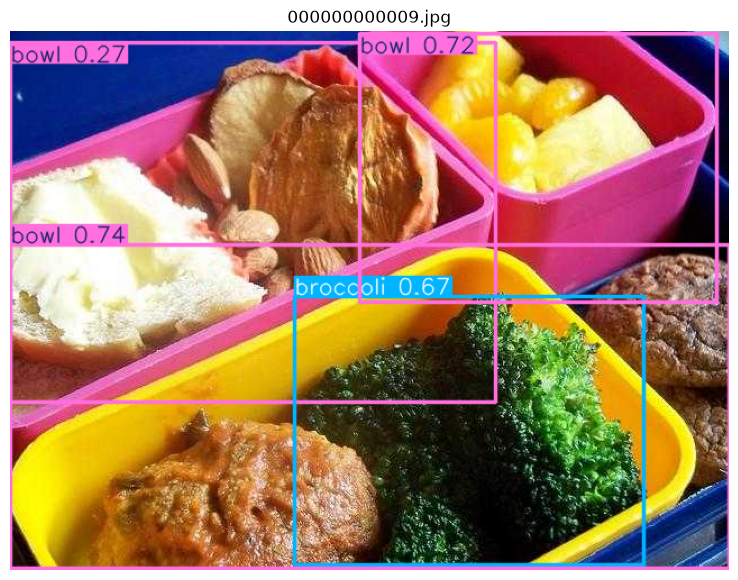

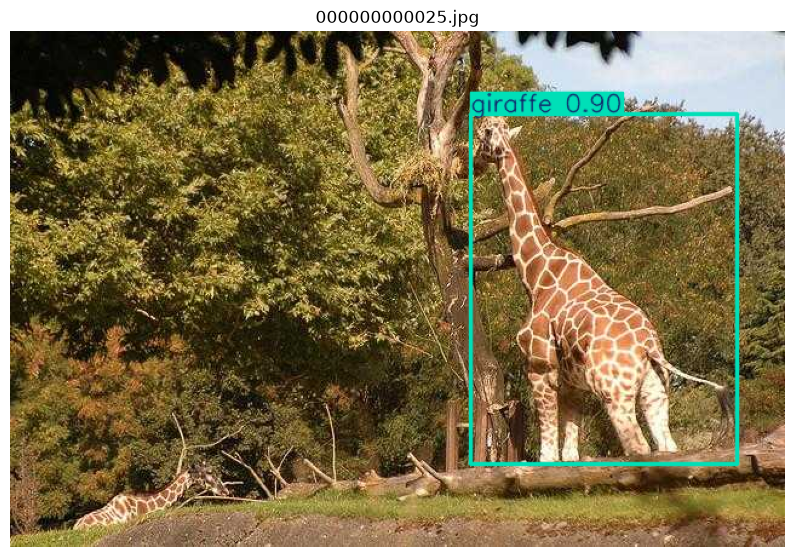

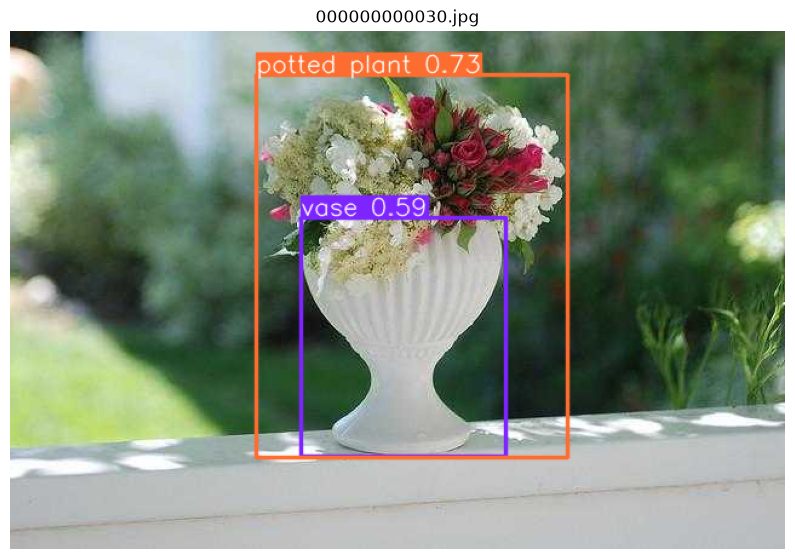

In [6]:
sample_images = image_candidates[:3]

for image_path in sample_images:
    results = model.predict(
        source=str(image_path),
        imgsz=416,
        conf=0.25,
        device="cpu",
        verbose=False
    )

    annotated = results[0].plot()
    plt.figure(figsize=(10, 7))
    plt.imshow(annotated[..., ::-1])
    plt.title(image_path.name)
    plt.axis("off")
    plt.show()

## 5. Inspect bounding boxes

Each detection contains `(x1, y1, x2, y2)`, confidence, and the predicted class.

In [7]:
result = model.predict(source=str(sample_images[0]), imgsz=416, conf=0.25, device="cpu", verbose=False)[0]

for box in result.boxes:
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    confidence = float(box.conf[0])
    class_id = int(box.cls[0])
    label = result.names[class_id]
    print(f"{label:15s} confidence={confidence:.2f} box=({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f})")

bowl            confidence=0.74 box=(0.0, 190.8, 640.0, 478.8)
bowl            confidence=0.72 box=(311.3, 2.0, 629.2, 241.4)
broccoli        confidence=0.67 box=(253.8, 236.4, 564.5, 475.9)
bowl            confidence=0.27 box=(0.1, 10.5, 432.8, 330.5)


## 6. Quick CPU validation on COCO8

This optional cell evaluates the pretrained model against the small sample dataset. It is intentionally kept small for CPU machines. You can skip it if you only need inference.

In [8]:
metrics = model.val(
    data="coco8.yaml",
    imgsz=320,
    batch=1,
    device="cpu",
    verbose=False
)
print("Validation completed.")
print("mAP50-95:", float(metrics.box.map))

Ultralytics 8.4.159  Python-3.14.6 torch-2.14.0+cpu CPU (Intel Core i5-6200U 2.30GHz)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

WARNING Dataset 'coco8.yaml' images not found, missing path 'C:\Users\user\Desktop\Object-Detection-with-YOLO\notebooks\datasets\coco8\images\val'
Unzipping C:\Users\user\Desktop\Object-Detection-with-YOLO\notebooks\datasets\coco8.zip to C:\Users\user\Desktop\Object-Detection-with-YOLO\notebooks\datasets\coco8...: 100% ━━━━━━━━━━━━ 25/25 364.3files/s 0.1s
Dataset download success  (22.2s), saved to C:\Users\user\Desktop\Object-Detection-with-YOLO\notebooks\datasets

WARNING val: Slow image access detected (ping: 0.10.0 ms, read: 5.52.9 MB/s, size: 54.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning C:\Users\user\Desktop\Object-Detection-with-YOLO\notebooks\datasets\coco8\labels\val... 4 images, 0 backgrounds, 0 co

## 7. Interview talking points

- **YOLO:** You Only Look Once treats object detection as a single neural-network inference problem.
- **Bounding box:** `(x1, y1, x2, y2)` localizes an object in the image.
- **Confidence:** The model estimates how confident it is in each prediction.
- **NMS:** Non-Maximum Suppression removes overlapping duplicate detections.
- **Nano model:** `yolov8n` is used here because the project targets CPU-only development and low disk usage.
- **Deployment:** The same inference workflow is exposed through the Flask web app in the repository root.